In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import chess
from stockfish import Stockfish

In [83]:
DB_PATH = "F:/databases/chess.db"
STOCKFISH_PATH = r"C:\Users\maxol\chess\engines\stockfish\stockfish-windows-x86-64-avx2"
stockfish = Stockfish(STOCKFISH_PATH)

cnxn = sqlite3.connect(DB_PATH)
cursor = cnxn.cursor()

In [84]:
search_df = pd.read_sql_query('SELECT * FROM searches', cnxn)
it_dep_df = pd.read_sql_query('SELECT * FROM searches_by_iteration', cnxn)
t_ply_df = pd.read_sql_query('SELECT * FROM searches_by_tree_depth', cnxn)
game_df = pd.read_sql_query('SELECT * FROM games', cnxn)

search_df['game_id'] = search_df['game_id'].astype('Int64')

#print(len(search_df), len(depth_df))
display(search_df.tail())
display(t_ply_df.head())
display(game_df.head())

,id,engine_id,game_id,sts_id,fen,ply,time_ms,eval,depth,qdepth,...,tt_fill,fail_highs,fail_lows,fail_high_first,fail_high_late,fail_high_researches,fail_low_researches,see_prunes,delta_prunes,ingestion_timestamp_utc
2939,2940,2,<NA>,2.0,1r1r2k1/2pq3p/4p3/2Q1Pp2/1PNn1R2/P5P1/5P1P/4R2...,2,100.0,-572,5,14,...,0.0,18072,1599,18072,0,0,0,26413,10102,2026-01-22 04:26:31
2940,2941,2,<NA>,2.0,8/5p1p/3P1k2/p1P2n2/3rp3/1B6/P4R2/6K1 w - - 0 1,1,100.0,-161,6,12,...,0.0,24168,2559,24168,0,0,0,20336,6113,2026-01-22 04:26:31
2941,2942,2,<NA>,2.0,2rbrnk1/1b3p2/p2pp3/1p4PQ/1PqBPP2/P1NR4/2P4P/5...,2,100.0,-112,5,16,...,0.0,12407,1728,12407,0,0,0,24573,6078,2026-01-22 04:26:31
2942,2943,2,<NA>,2.0,4r1k1/1bq2r1p/p2p1np1/3Pppb1/P1P5/1N3P2/1R2B1P...,1,100.0,144,4,15,...,0.0,17825,753,17825,0,0,0,42779,5613,2026-01-22 04:26:31
2943,2944,2,<NA>,2.0,8/8/8/8/4kp2/1R6/P2q1PPK/8 w - - 0 1,1,100.0,-593,8,11,...,0.0,24698,4153,24698,0,0,0,5516,2296,2026-01-22 04:26:31


,search_id,depth,nodes,qnodes,tt_stores,tt_hits,fail_highs,fail_lows,fail_high_first,fail_high_late,see_prunes,delta_prunes,ingestion_timestamp_utc
0,1,1,226,89,119,0,27,0,27,0,13,0,2026-01-22 04:26:18
1,1,2,2508,622,1788,0,1711,0,1711,0,169,12,2026-01-22 04:26:18
2,1,3,6163,4081,4283,151,2473,525,2473,0,1846,110,2026-01-22 04:26:18
3,1,4,27287,7255,3166,0,2770,0,2770,0,2761,140,2026-01-22 04:26:18
4,2,1,250,113,140,0,38,0,38,0,11,0,2026-01-22 04:26:18


,id,experiment_id,white_engine_id,black_engine_id,wtime,winc,btime,binc,movestogo,depth,nodes,movetime,result,termination,opening,start_fen,moves,run_time_s,ingestion_timestamp_utc
0,1,1,1,2,0,0,0,0,0,-1,-1,100,2,1,None,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,"[""c2c4"", ""c7c5"", ""g2g3"", ""g7g6"", ""f1g2"", ""f8g7...",10.3126,2026-01-22 04:26:12
1,2,1,2,1,0,0,0,0,0,-1,-1,100,1,1,None,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,"[""e2e4"", ""e7e6"", ""d2d4"", ""d7d5"", ""e4e5"", ""c7c5...",13.4372,2026-01-22 04:26:12
2,3,1,1,2,0,0,0,0,0,-1,-1,100,1,1,None,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,"[""e2e4"", ""e7e6"", ""d2d4"", ""d7d5"", ""e4e5"", ""c7c5...",13.9177,2026-01-22 04:26:12
3,4,1,2,1,0,0,0,0,0,-1,-1,100,1,1,None,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,"[""e2e4"", ""e7e6"", ""d2d4"", ""d7d5"", ""b1d2"", ""a7a6...",20.6590,2026-01-22 04:26:12
4,5,1,1,2,0,0,0,0,0,-1,-1,100,1,1,None,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,"[""e2e4"", ""e7e6"", ""d2d4"", ""d7d5"", ""b1d2"", ""a7a6...",15.3656,2026-01-22 04:26:12


In [85]:
depths_df = it_dep_df.groupby('search_id')[['depth']].max().merge(
    t_ply_df.groupby('search_id')[['depth']].max(),
    left_index=True,
    right_index=True,
    how='outer',
    suffixes=('_itdep','_tdep')
)

depths_df

,depth_itdep,depth_tdep
search_id,,
1,4,4
2,5,5
3,4,4
4,4,4
5,4,4
...,...,...
2940,5,5
2941,6,6
2942,5,5


In [86]:
# Map string results to numeric for convenience
result_map = {'white_win': 1, 'black_win': 0, 'draw': 0.5}
game_df['result_str'] = game_df['result'].map({'1':'white_win','2':'black_win','3':'draw'})
game_df['numeric_result'] = game_df['result_str'].map(result_map)

# Merge numeric game result into search_df
search_df = search_df.merge(game_df[['id','numeric_result','result_str']], left_on='game_id', right_on='id', how='left')

# Determine engine perspective
def engine_score(row):
    if row['ply'] % 2 == 1:  # engine is white
        return row['numeric_result']
    else:                     # engine is black
        return 1 - row['numeric_result'] if row['numeric_result'] != 0.5 else 0.5
    
def engine_eval(row):
    if row['ply'] % 2 == 1: # engine is white
        return row['eval']
    else:
        return -row['eval']

search_df['engine_score'] = search_df.apply(engine_score, axis=1)
#search_df['engine_eval'] = search_df.apply(engine_eval, axis=1)

search_df#[search_df['ply']==50]

,id_x,engine_id,game_id,sts_id,fen,ply,time_ms,eval,depth,qdepth,...,fail_high_late,fail_high_researches,fail_low_researches,see_prunes,delta_prunes,ingestion_timestamp_utc,id_y,numeric_result,result_str,engine_score
0,1,2,<NA>,NaN,r1bqk1nr/pp1pppbp/2n3p1/2p5/2P5/2N3P1/PP1PPPBP...,9,131.0,30,4,14,...,0,0,0,4789,262,2026-01-22 04:26:13,NaN,NaN,NaN,NaN
1,2,2,1,NaN,r1bqk1nr/pp1pppbp/2n3p1/2p5/2P5/2NP2P1/PP2PPBP...,10,130.0,-18,5,13,...,0,0,0,4499,265,2026-01-22 04:26:13,1.0,0.0,black_win,1.0
2,3,2,<NA>,NaN,r1bqk1nr/pp2ppbp/2np2p1/2p5/2P5/2NP2P1/PP2PPBP...,11,131.0,29,4,14,...,0,0,0,6061,454,2026-01-22 04:26:13,NaN,NaN,NaN,NaN
3,4,2,1,NaN,r1bqk1nr/pp2ppbp/2np2p1/2p5/2P5/2NP2P1/PP1BPPB...,12,128.0,-2,4,16,...,0,0,0,5810,805,2026-01-22 04:26:13,1.0,0.0,black_win,1.0
4,5,2,<NA>,NaN,r1bqk1nr/pp3pbp/2npp1p1/2p5/2P5/2NP1NP1/PP2PPB...,13,128.0,27,4,13,...,0,0,0,3801,717,2026-01-22 04:26:13,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2939,2940,2,<NA>,2.0,1r1r2k1/2pq3p/4p3/2Q1Pp2/1PNn1R2/P5P1/5P1P/4R2...,2,100.0,-572,5,14,...,0,0,0,26413,10102,2026-01-22 04:26:31,NaN,NaN,NaN,NaN
2940,2941,2,<NA>,2.0,8/5p1p/3P1k2/p1P2n2/3rp3/1B6/P4R2/6K1 w - - 0 1,1,100.0,-161,6,12,...,0,0,0,20336,6113,2026-01-22 04:26:31,NaN,NaN,NaN,NaN
2941,2942,2,<NA>,2.0,2rbrnk1/1b3p2/p2pp3/1p4PQ/1PqBPP2/P1NR4/2P4P/5...,2,100.0,-112,5,16,...,0,0,0,24573,6078,2026-01-22 04:26:31,NaN,NaN,NaN,NaN
2942,2943,2,<NA>,2.0,4r1k1/1bq2r1p/p2p1np1/3Pppb1/P1P5/1N3P2/1R2B1P...,1,100.0,144,4,15,...,0,0,0,42779,5613,2026-01-22 04:26:31,NaN,NaN,NaN,NaN


C:\Users\maxol\AppData\Local\Temp\ipykernel_10420\4230779684.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = search_df.groupby('eval_bin')['engine_score'].mean().reset_index()


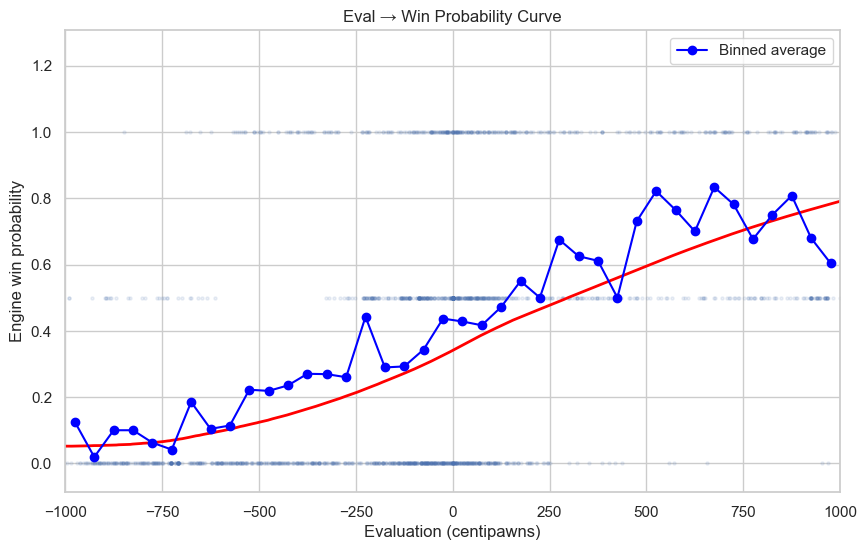

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

sns.set(style="whitegrid")
plt.figure(figsize=(10,6))

# --- Scatter + Lowess smoothing ---
sns.regplot(
    x='eval', 
    y='engine_score', 
    data=search_df, 
    lowess=True, 
    scatter_kws={'s':5, 'alpha':0.1},  # transparent scatter
    line_kws={'color':'red', 'linewidth':2}  # lowess line
)

# --- Binned average line ---
bin_width = 50
min_eval = -1000
max_eval = 1000
bins = np.arange(min_eval, max_eval + bin_width, bin_width)

search_df['eval_bin'] = pd.cut(search_df['eval'], bins)
binned = search_df.groupby('eval_bin')['engine_score'].mean().reset_index()
binned['eval_center'] = binned['eval_bin'].apply(lambda x: x.mid)

plt.plot(
    binned['eval_center'], 
    binned['engine_score'], 
    marker='o', 
    linestyle='-', 
    color='blue', 
    label='Binned average'
)

# --- Labels & aesthetics ---
plt.xlim(min_eval, max_eval)
plt.xlabel("Evaluation (centipawns)")
plt.ylabel("Engine win probability")
plt.title("Eval → Win Probability Curve")
plt.legend()
plt.grid(True)
plt.show()


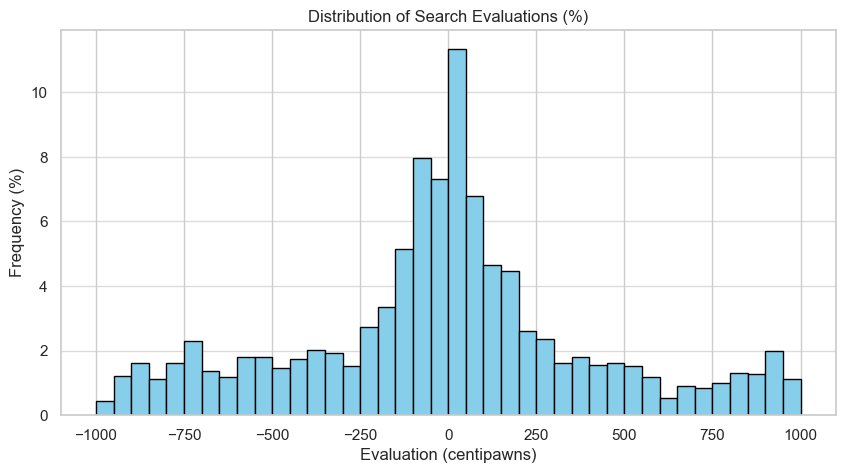

In [88]:
import matplotlib.pyplot as plt
import numpy as np

# Histogram parameters
bin_width = 50
min_eval = -1000
max_eval = 1000
bins = np.arange(min_eval, max_eval + bin_width, bin_width)

# Compute histogram
counts, edges = np.histogram(search_df['eval'], bins=bins)
percentages = counts / counts.sum() * 100  # convert to %

plt.figure(figsize=(10,5))
plt.bar(edges[:-1], percentages, width=bin_width, align='edge', color='skyblue', edgecolor='black')
plt.xlabel("Evaluation (centipawns)")
plt.ylabel("Frequency (%)")
plt.title("Distribution of Search Evaluations (%)")
plt.grid(axis='y', alpha=0.7)
plt.show()


In [89]:
def stockfish_eval(fen, depth=10):
    stockfish.set_fen_position(fen)

    info = stockfish.get_evaluation()
    # info = {'type': 'cp', 'value': 23} or {'type': 'mate', 'value': 3}

    side_to_move = fen.split()[1]  # 'w' or 'b'

    if info["type"] == "cp":
        value = info["value"]  # centipawns, from White's perspective

        # Flip if Black is to move
        if side_to_move == "b":
            value = -value

        return value

    else:  # mate score
        # Stockfish: positive = White mates, negative = Black mates
        mate_value = 100000 if info["value"] > 0 else -100000

        # Flip to side-to-move perspective
        if side_to_move == "b":
            mate_value = -mate_value

        return mate_value


In [90]:
full_search_df = pd.read_sql_query(
    """
    SELECT sbd.*, s.fen
    FROM searches_by_depth sbd
    JOIN searches s ON sbd.search_id = s.id
    """,
    cnxn
)

full_search_df['sf_eval'] = full_search_df['fen'].apply(stockfish_eval)
full_search_df['elo_diff'] = full_search_df['eval'] - full_search_df['sf_eval']

display(full_search_df)

DatabaseError: Execution failed on sql '
    SELECT sbd.*, s.fen
    FROM searches_by_depth sbd
    JOIN searches s ON sbd.search_id = s.id
    ': no such table: searches_by_depth

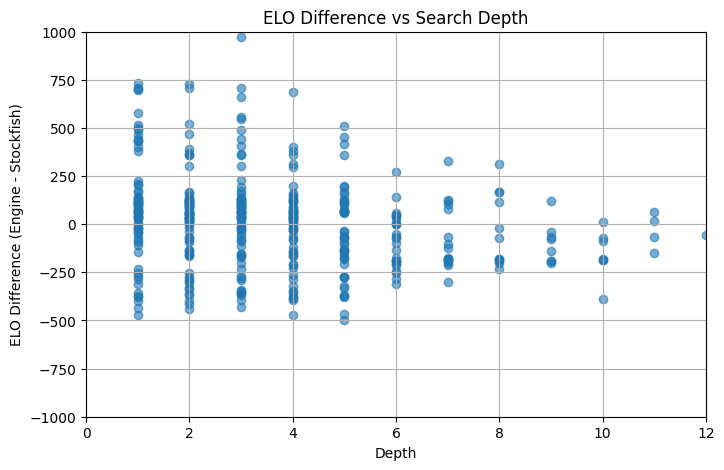

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(full_search_df["depth"], full_search_df["elo_diff"], alpha=0.6)
plt.ylim(-1000,1000)
plt.xlim(0,12)
plt.xlabel("Depth")
plt.ylabel("ELO Difference (Engine - Stockfish)")
plt.title("ELO Difference vs Search Depth")
plt.grid(True)
plt.show()


In [ ]:
import pandas as pd

# Path to your JSONL file
jsonl_file = "../logs/sprt_logs/search.jsonl"

# Read into a DataFrame
df = pd.read_json(jsonl_file, lines=True)

# Quick check
print(df.head())
print(df.columns)


  engine_id  instance_id    type  session  \
0     1.1.0        11068  search        2   
1     1.1.0        29768  search        2   
2     1.1.0        11068  search        2   
3     1.1.0        29768  search        2   
4     1.1.0        11068  search        2   

                              game_uuid                           search_uuid  \
0  2edb8881-edb1-477c-bf43-6d5c21d5b491  3107577c-0619-4212-b270-15409c890f2b   
1  5503729d-52d8-43cc-a668-a632f73134a7  68f94c03-ba74-40a2-a492-4c90d32c5d72   
2  2edb8881-edb1-477c-bf43-6d5c21d5b491  5c5fae44-2909-4cb2-b9fe-12e7dfd56fa3   
3  5503729d-52d8-43cc-a668-a632f73134a7  ed1a205a-42a4-4235-addf-7cd88f85a871   
4  2edb8881-edb1-477c-bf43-6d5c21d5b491  d340847a-cc92-474b-809b-5d7f5db6ec2b   

                                                 fen  ply  nodes  qnodes  ...  \
0  r1bqk1nr/pp1pppbp/2n3p1/2p5/2P5/2N3P1/PP1PPPBP...    9  18846    7953  ...   
1  r1bqk1nr/pp1pppbp/2n3p1/2p5/2P5/2NP2P1/PP2PPBP...   10  58585   16056  ...   

In [ ]:
df.groupby(['search_uuid','ply']).count().sort_values('engine_id')

,,engine_id,instance_id,type,session,game_uuid,fen,nodes,qnodes,tt_hits,tt_stores,...,treedepth_nodes,treedepth_qnodes,treedepth_tt_hits,treedepth_tt_stores,treedepth_fail_highs,treedepth_fail_lows,treedepth_fail_high_firsts,treedepth_fail_high_lates,treedepth_see_prunes,treedepth_delta_prunes
search_uuid,ply,,,,,,,,,,,,,,,,,,,,,
002f8a92-04f8-4b0f-9662-c016e7263298,63,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
01cb8d0d-aaf7-4dc5-ac29-03d163d85c71,61,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
01e7aaae-29f2-45ff-a1e1-dc732c6ee866,61,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
01f07c14-f3ba-4a7c-8275-2892dc9b3cba,240,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
03ea19e2-2851-4e49-be5f-c29a762b90e1,39,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
f9a00b77-6695-427e-9a0e-6ee07fc95169,188,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
fa344212-7a57-4548-8d9d-c9e706f91c97,196,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
fdc627b1-dc68-4350-afe5-d77a2b77ee5d,192,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
